In [1]:
import json
import sys
import re

import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import tensorflow as tf

from pathlib import Path

2025-11-12 15:23:03.459704: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-12 15:23:03.509662: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-12 15:23:03.509705: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-12 15:23:03.510745: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-12 15:23:03.517785: I tensorflow/core/platform/cpu_feature_guar

In [2]:
src_path = Path('/gpfs/work2/0/prjs1027/tfrecords/')
tfrecord_dir = src_path / 'run4'
write_dir = Path("/gpfs/work2/0/prjs1027/guus/data")
bathymetry_path = write_dir / 'swan-ns-j22_6-v1a_adjust.bot'
valid_mask = np.load(src_path / "run4/valid-mask.npy")

In [3]:
batch_size = 16

model_version = "turbo_swan_v0023"
ens_nrs = [26, 27, 28, 29, 30] 

model_dir = Path('/gpfs/work2/0/prjs1027/guus/trained_models/') / f'{model_version}'
model_dir.mkdir(exist_ok=True, parents=True)

sys.path.append(str(model_dir / 'train-network'))

In [4]:
import create_datasets
import preprocessing_utils

In [5]:
with open(src_path / 'run4/train-test-split-years.json', 'r') as f:
    train_test_split = json.load(f)

val_years = train_test_split['validation']

In [6]:
paths = list((src_path / 'run4/val_data').glob(f'*{val_years[0]}*.tfrecords'))

In [7]:
def load_val_ds(ens_nr):
    val_ds = xr.load_dataset(write_dir / f'validation_ens{ens_nr}.nc')
    bc_ds = xr.open_dataset(write_dir / "BoundaryConditions/bnd.nc")
    
    # val_ds['wl'] = val_ds['ssh'] + bathymetry
    # test_ds = xr.concat([val_ds.sel(time=slice_) for slice_ in time_chunks['test_blocks']], dim='time')
    
    return val_ds

In [8]:
test_ds = load_val_ds(26)

In [9]:
def sort_key(path, year):
    name = path.name
    # Extract x (first number), y (after H), z (after t)
    match = re.search(rf'^(\d+)_\d+_y{year}_H(\d+)_t(\d+)_\d+\.tfrecords$', name)
    if match:
        x = int(match.group(1))
        y = int(match.group(2))
        z = int(match.group(3))
        return (y, z, x)
    else:
        return (0, 0, 0)  # fallback if pattern doesn't match

sorted_paths = sorted(paths, key=lambda x: sort_key(x, year=1995))


In [10]:
output_variables = ["hs"]
input_variables_original = ["xwnd", "ywnd", "wl"]
input_variables = ["xwnd", "ywnd", "wl"]
boundary_variables = ["hs_bnd", "tp_bnd", "theta0_bnd"]
# boundary_variables = ["hs_bnd", "tmm10_bnd", "theta0_bnd"]
variable_fields = input_variables_original + output_variables + boundary_variables

valid_mask = np.load(tfrecord_dir / "valid-mask.npy")

learning_rate = 1e-4
n_epochs = 50
batch_size = 32
steps_per_execution = 1

raster_shape = (481, 421, 2 * len(input_variables))
boundary_shape = (106, len(boundary_variables))
widths = [16, 32, 64, 128, 256, 256]
block_depth = 3

seed = 0

min_max_ds = create_datasets.load_min_max_ds(
    tfrecord_dir / "min_max_files/min-max-values-all.nc",
    boundary_variables=boundary_variables,
)

# year_ds = create_datasets.get_dataset(
#     files=sorted_paths,
#     min_max_ds=min_max_ds,
#     variable_fields=variable_fields,
#     input_variables=input_variables,
#     output_variables=output_variables,
#     boundary_variables=boundary_variables,
#     indices=[3],
#     valid_mask=valid_mask
# )

# year_ds = year_ds.batch(1, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

2025-11-12 15:23:30.760493: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38479 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:ca:00.0, compute capability: 8.0


In [11]:
def create_dataset(year):
    paths = list((src_path / 'run4/val_data').glob(f'*{year}*.tfrecords'))
    sorted_paths = sorted(paths, key=lambda x: sort_key(x, year=year))

    year_ds = create_datasets.get_dataset(
        files=sorted_paths,
        min_max_ds=min_max_ds,
        variable_fields=variable_fields,
        input_variables=input_variables,
        output_variables=output_variables,
        boundary_variables=boundary_variables,
        indices=[1, 3],
        valid_mask=valid_mask
    )
    
    year_ds = year_ds.batch(1, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

    return year_ds

In [12]:
def masked_loss(mask):
    def loss(y_true, y_pred):
        mask_expanded = tf.expand_dims(mask, axis=0)
        mask_tiled = tf.tile(mask_expanded, [tf.shape(y_true)[0], 1, 1])

        masked_true = tf.boolean_mask(y_true, mask_tiled)
        masked_pred = tf.boolean_mask(y_pred, mask_tiled)

        theta0_true = denormalize(masked_true[..., 1], var="theta0")
        theta0_pred = denormalize(masked_pred[..., 1], var="theta0")

        diff = masked_true - masked_pred
        diff_theta = circular_error(theta0_true, theta0_pred, to_rad=True)

         # Use TensorFlow operations to modify the tensor
        diff = tf.concat([diff[..., :1], tf.expand_dims(diff_theta, axis=-1), diff[..., 2:]], axis=-1)


        mse = K.mean(tf.square(diff))
        return mse
    return loss

In [13]:
model = tf.keras.models.load_model(model_dir / (model_version + '.h5'), custom_objects={'loss': masked_loss})
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 481, 421, 6)]        0         []                            
                                                                                                  
 zero_padding2d (ZeroPaddin  (None, 512, 512, 6)          0         ['input_1[0][0]']             
 g2D)                                                                                             
                                                                                                  
 batch_normalization (Batch  (None, 512, 512, 6)          24        ['zero_padding2d[0][0]']      
 Normalization)                                                                                   
                                                                                              

In [14]:
def normalize(data, var):
    data = (data - min_max_ds[var].values[0]) / (min_max_ds[var].values[1] - min_max_ds[var].values[0])
    return data

def denormalize(data, var):
    data = data * (min_max_ds[var].values[1] - min_max_ds[var].values[0]) + min_max_ds[var].values[0]
    return data

In [15]:
def make_predictions(model, val_ds, denormalize_vals=True):
    ens_30_pred = {var: [] for var in output_variables}
    ens_30_true = {var: [] for var in output_variables}
    ii = 0
    for element in val_ds:
        input_data = element[0]
        output_data = element[1]
        valid_mask = output_data[..., -1].numpy()

        pred = model.predict((input_data[0], input_data[1]))
        for i, var in enumerate(output_variables):
            if denormalize_vals:
                prediction = denormalize(pred, var)[ ..., i]
                truth = denormalize(output_data, var)[ ..., i]
                if var == 'theta0':
                    prediction = prediction % 360
                    truth = truth % 360
    
                prediction = np.clip(prediction, a_min=0, a_max=None)
                truth = np.clip(truth, a_min=0, a_max=None)
            else:
                prediction = pred[..., i]
                truth = output_data[..., i].numpy()
            
            prediction[valid_mask == 0] = np.nan
            truth[valid_mask == 0] = np.nan

            prediction = prediction[0, ...]
            truth = truth[0, ...]
            
            ens_30_pred[var].append(prediction)
            ens_30_true[var].append(truth)
        ii += 1
        # if ii == 10:
        #     break

    return ens_30_pred, ens_30_true
    

In [16]:
def create_pred_ds(pred_values, true_values, year, test_ds=test_ds):
    dataset_dict = {}
    for var, data in pred_values.items():
        dataset_dict[f'{var}_pred'] = (["time", "latitude", "longitude"], data)
    
    for var, data in true_values.items():
        dataset_dict[f'{var}_swan'] = (["time", "latitude", "longitude"], data)
    
    # times = test_ds.time.values
    times = range(len(pred_values['hs']))
    coords = {
        "time": times,
        "latitude": test_ds.latitude.values,
        "longitude": test_ds.longitude.values,
    }
    
    pred_ds = xr.Dataset(dataset_dict, coords=coords)
    pred_ds = pred_ds.assign_coords({'time': pd.date_range(start=f'{year}-01-01 00:00:00', periods=pred_ds.time.shape[0], freq='1H')})

    return pred_ds

In [17]:
def save_pred_ds(pred_ds, ens_nr):
    version_number = model_version.split('_')[-1]
    pred_ds.to_netcdf(model_dir / f'turboswan-{version_number}-ens{year}-test-predictions.nc')

In [18]:
# for year in val_years:
for year in [1994]:
    year_ds = create_dataset(year)
    pred_values, true_values = make_predictions(model, val_ds=year_ds, denormalize_vals=True)

    pred_ds = create_pred_ds(pred_values, true_values, year=year)
    save_pred_ds(pred_ds, year)

2025-11-12 15:24:01.312848: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902


1/1 [==============================] - 0s 31ms/step


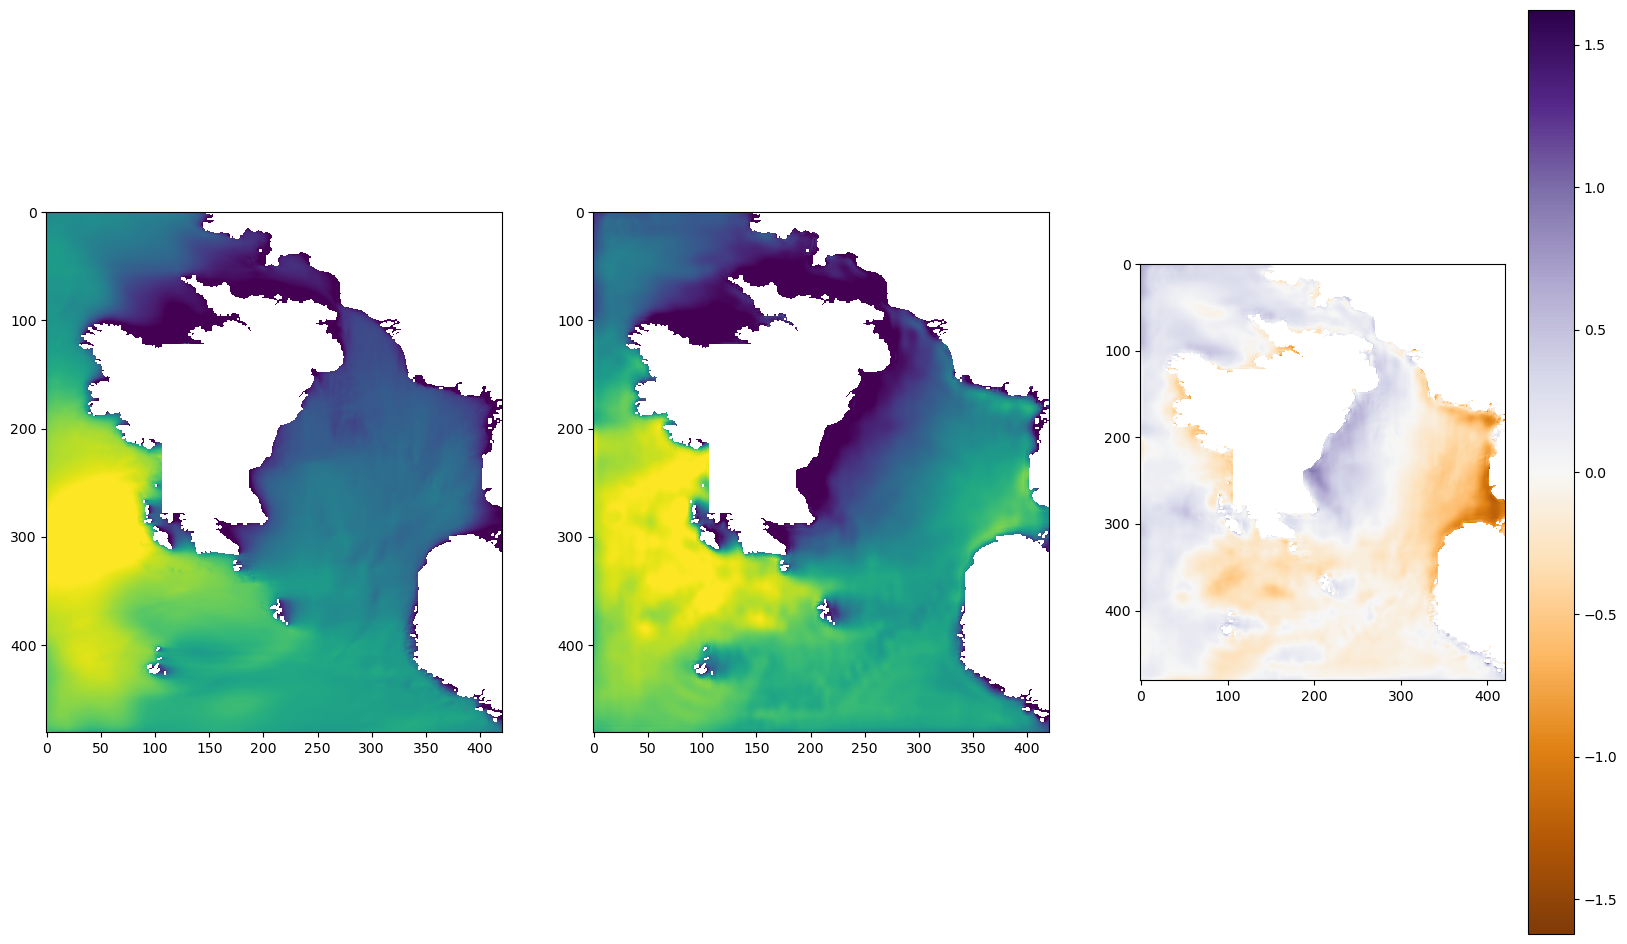

In [19]:
var = 'hs'
i = 2630
theta_true = true_values[var][i]
theta_pred = pred_values[var][i]
if var == 'theta0':
    theta_error = circular_error(theta_true, theta_pred)
else:
    theta_error = theta_true - theta_pred

vmin, vmax = np.nanquantile(theta_true, [0.05, 0.95])
error_max = np.nanmedian(theta_true)
vmin_e, vmax_e = -error_max, error_max
cmap = 'twilight_shifted' if var == 'theta0' else 'viridis'
fig, axes = plt.subplots(ncols=3, figsize=(20, 12))
im_true = axes[0].imshow(theta_true, vmin=vmin, vmax=vmax, cmap=cmap)
im_pred = axes[1].imshow(theta_pred, vmin=vmin, vmax=vmax, cmap=cmap)
im_error = axes[2].imshow(theta_error, cmap='PuOr', vmin=vmin_e, vmax=vmax_e)
# plt.colorbar(im_true)
# plt.colorbar(im_pred)
plt.colorbar(im_error)

In [19]:
pred_ds

<xarray.Dataset>
Dimensions:    (time: 8838, latitude: 481, longitude: 421)
Coordinates:
  * time       (time) datetime64[ns] 1994-01-01 ... 1995-01-04T05:00:00
  * latitude   (latitude) float32 48.0 48.03 48.07 48.1 ... 63.93 63.97 64.0
  * longitude  (longitude) float32 -12.0 -11.95 -11.9 -11.85 ... 8.9 8.95 9.0
Data variables:
    hs_pred    (time, latitude, longitude) float32 4.103 4.101 ... 3.816 3.774
    hs_swan    (time, latitude, longitude) float32 1.666 1.664 ... 1.32 1.312

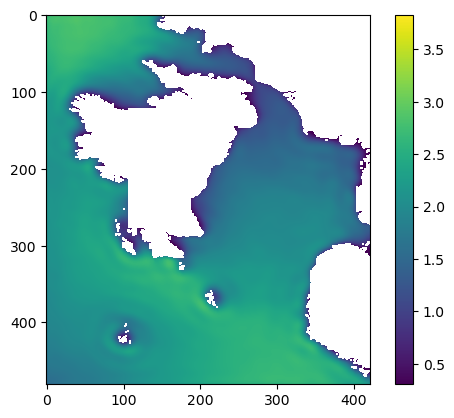

In [20]:
fig, ax = plt.subplots()
vmin, vmax = np.nanquantile(theta_true * 17, [0.05, 0.95])
im = ax.imshow(theta_pred * 17, vmin=vmin, vmax=vmax)
plt.colorbar(im)

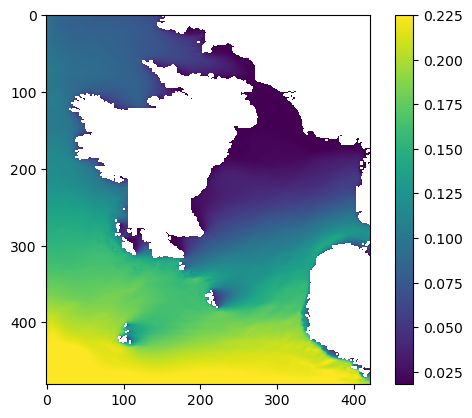

In [21]:
fig, ax = plt.subplots()
vmin, vmax = np.nanquantile(theta_true, [0.05, 0.95])
im = ax.imshow(theta_true, vmin=vmin, vmax=vmax)
plt.colorbar(im)

In [22]:
np.nanmean(theta_error**2)

0.03439665

In [48]:
np.nanmean(abs(theta_error))

0.06134944

In [45]:
3.5 / 17

0.20588235294117646

In [35]:
min_max_ds['hs']

<xarray.DataArray 'hs' (index: 2)>
array([ 0.      , 17.873928])
Coordinates:
  * index    (index) object 'minimum' 'maximum'

In [41]:
pred_ds['hs_pred'].shape

(8838, 481, 421)

In [46]:
hs_at_random_point = []
for i in range(pred_ds['hs_swan'].shape[0]):
    hs = pred_ds['hs_swan'][i, 110, 112]
    hs_at_random_point.append(hs)


In [43]:
# hs_at_random_point = []
# for element in year_ds:
#     hs = element[1][110, 112, 0]
#     hs_at_random_point.append(hs)
    

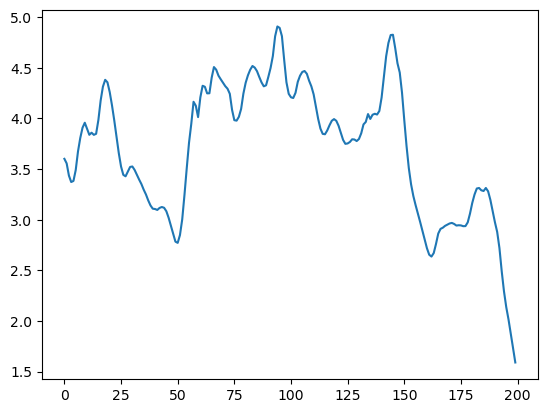

In [47]:
import matplotlib.pyplot as plt

plt.plot(hs_at_random_point[:200])

In [48]:
sorted_paths

[PosixPath('/gpfs/work2/0/prjs1027/tfrecords/run4/val_data/1_10_y1995_H1_t9_10.tfrecords'),
 PosixPath('/gpfs/work2/0/prjs1027/tfrecords/run4/val_data/2_10_y1995_H1_t9_10.tfrecords'),
 PosixPath('/gpfs/work2/0/prjs1027/tfrecords/run4/val_data/3_10_y1995_H1_t9_10.tfrecords'),
 PosixPath('/gpfs/work2/0/prjs1027/tfrecords/run4/val_data/4_10_y1995_H1_t9_10.tfrecords'),
 PosixPath('/gpfs/work2/0/prjs1027/tfrecords/run4/val_data/5_10_y1995_H1_t9_10.tfrecords'),
 PosixPath('/gpfs/work2/0/prjs1027/tfrecords/run4/val_data/6_10_y1995_H1_t9_10.tfrecords'),
 PosixPath('/gpfs/work2/0/prjs1027/tfrecords/run4/val_data/7_10_y1995_H1_t9_10.tfrecords'),
 PosixPath('/gpfs/work2/0/prjs1027/tfrecords/run4/val_data/8_10_y1995_H1_t9_10.tfrecords'),
 PosixPath('/gpfs/work2/0/prjs1027/tfrecords/run4/val_data/9_10_y1995_H1_t9_10.tfrecords'),
 PosixPath('/gpfs/work2/0/prjs1027/tfrecords/run4/val_data/10_10_y1995_H1_t9_10.tfrecords'),
 PosixPath('/gpfs/work2/0/prjs1027/tfrecords/run4/val_data/1_10_y1995_H2_t9_10.